In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [3]:
import os
print(os.path.expanduser("~"))

/Users/eri


In [4]:
df = pd.read_csv("/Users/eri/desktop/music_streams.csv")

In [5]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [6]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [9]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram


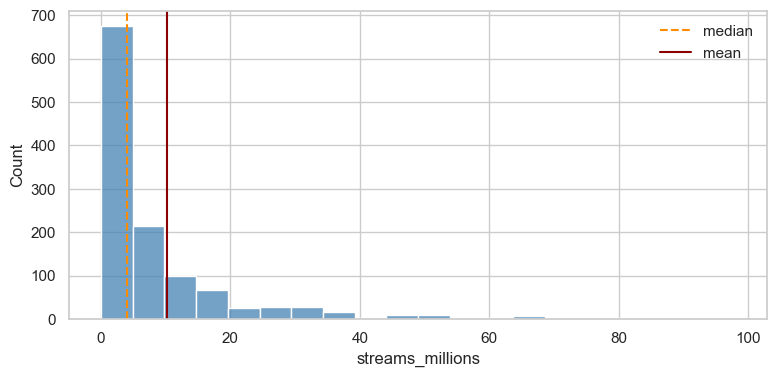

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20, ax=ax, color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label="median")
ax.axvline(mean, color="darkred", label="mean")
ax.legend(frameon=False)
plt.show()

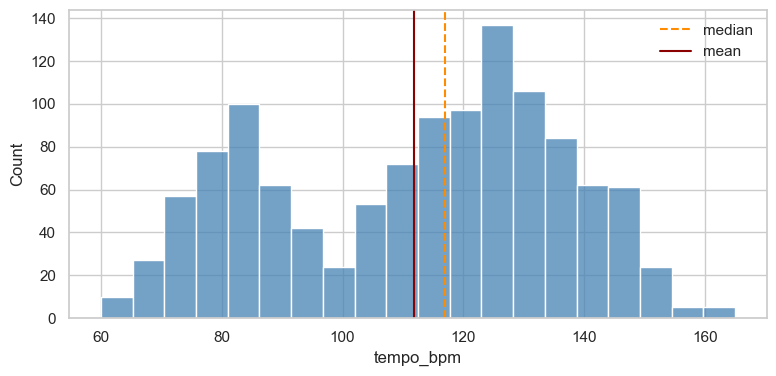

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x="tempo_bpm", bins=20, ax=ax, color="steelblue")
ax.axvline(df.tempo_bpm.median(), color="darkorange", linestyle="--", label="median")
ax.axvline(df.tempo_bpm.mean(), color="darkred", label="mean")
ax.legend(frameon=False)
plt.show()

## boxplot

In [15]:
order = df.groupby("genre")["energy"].median()
order

genre
Country       0.5720
Electronic    0.7810
Hip-Hop       0.6315
Indie         0.5515
Latin         0.6920
Pop           0.5805
R&B           0.4725
Rock          0.7440
Name: energy, dtype: float64

<Axes: xlabel='genre', ylabel='energy'>

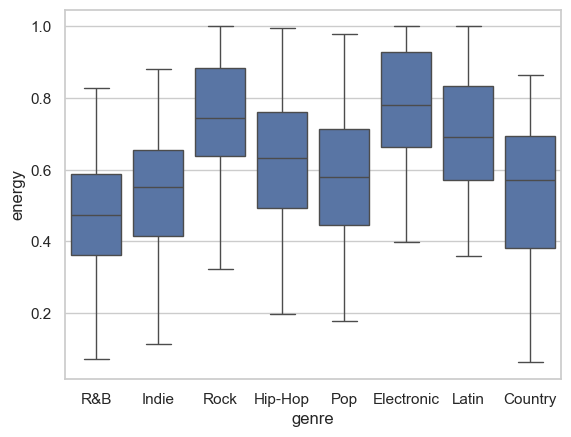

In [16]:
sns.boxplot(data=df, y="energy", x="genre")

<Axes: xlabel='genre', ylabel='monthly_listeners'>

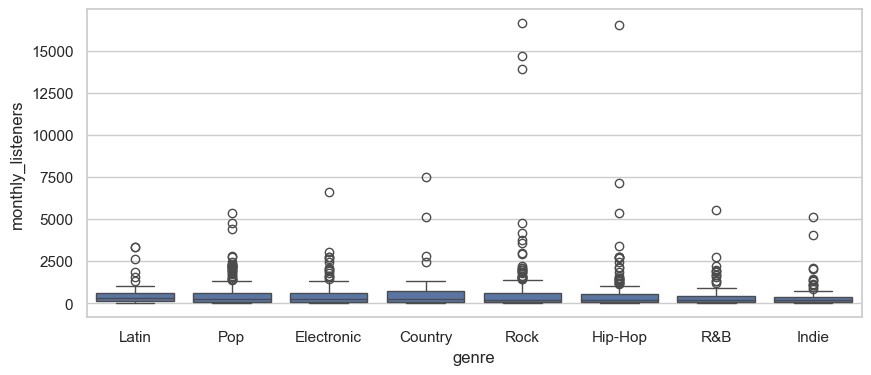

In [17]:
import numpy as np  

df["monthy_listeners_log"] = np.log(df["monthly_listeners"])
df["monthy_listeners_log"]

order = df.groupby("genre")["monthly_listeners"].median().sort_values(ascending=False).index
order
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, y="monthly_listeners", x="genre", order=order, ax=ax)

## Scatter Plot

<Axes: xlabel='energy', ylabel='danceability'>

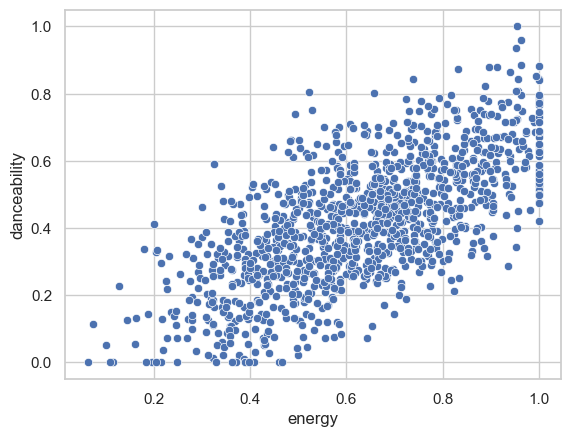

In [20]:
sample = df.sample(600)
sns.scatterplot(data=df, x="energy", y="danceability")

<Axes: xlabel='energy', ylabel='danceability'>

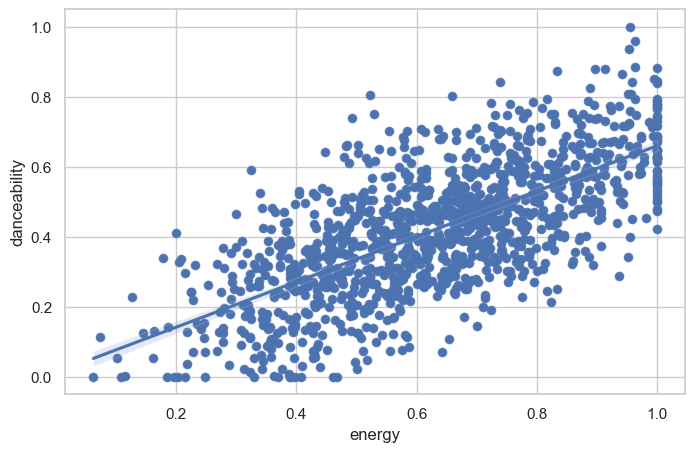

In [21]:
pythonsample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))  
sns.scatterplot(data=df, x="energy", y="danceability")
sns.regplot(data=df, x="energy", y="danceability") 

<Axes: xlabel='energy', ylabel='danceability'>

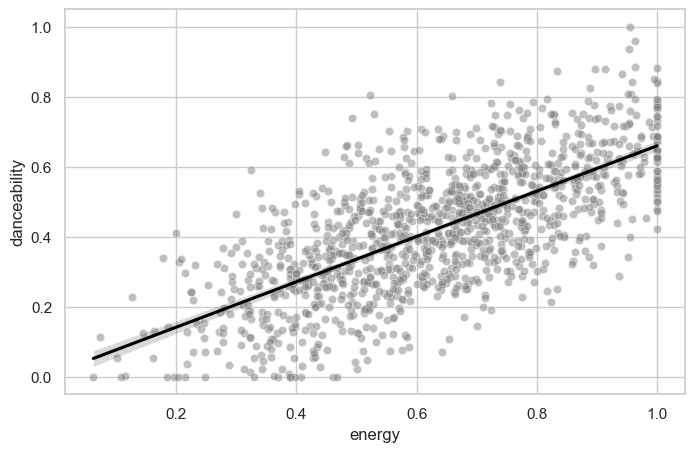

In [22]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="danceability", color="grey", alpha=0.5)
# color="grey" → make dot grey
# alpha=0.5 → low opacity

sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="black")
# scatter=False → doesn't showed regplot dot 
# color="black" 

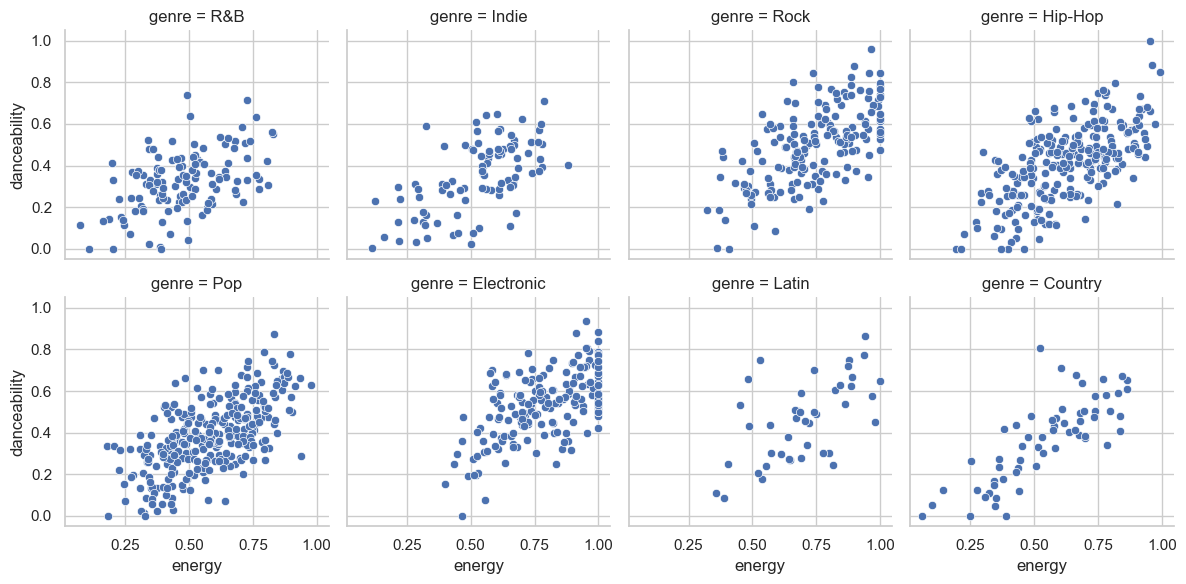

In [23]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

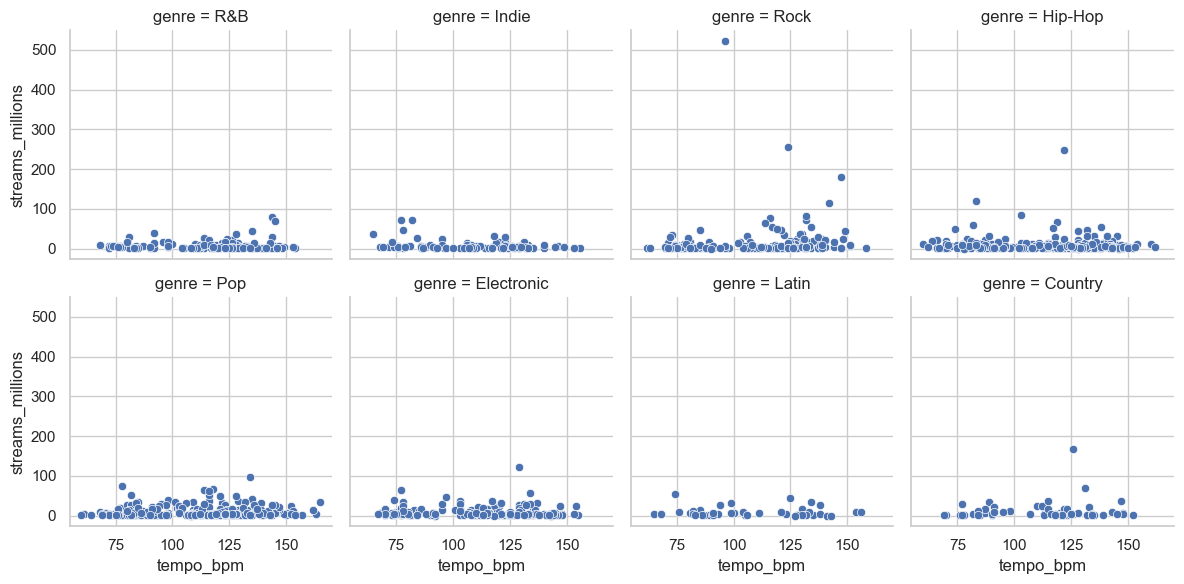

In [24]:

g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "tempo_bpm", "streams_millions")

<Axes: xlabel='danceability', ylabel='speechiness'>

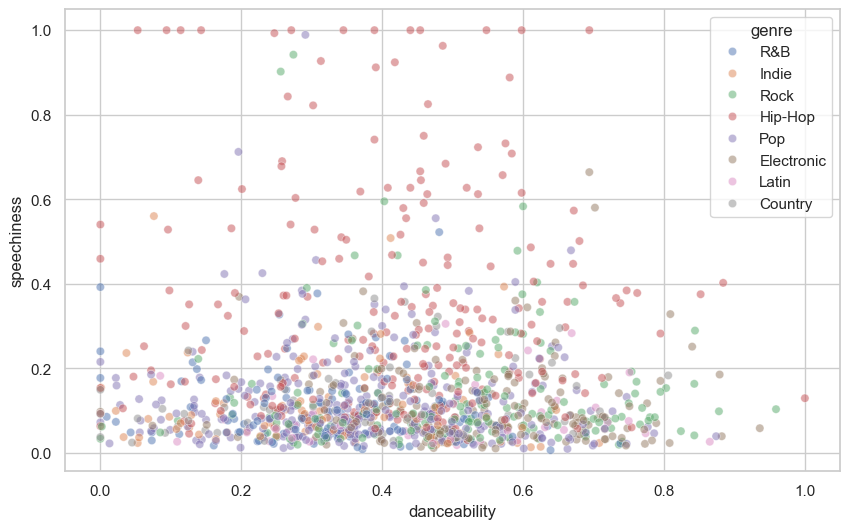

In [18]:
# lab3 task
pythonfig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="danceability", y="speechiness",
                hue="genre", alpha=0.5, ax=ax)

## Line chart and friends 

In [25]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label,monthy_listeners_log
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL,5.170484
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds,5.135798
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans,6.646391
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music,0.000000
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds,0.000000


In [26]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [27]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

year  genre     
2015  Electronic     6.040
      Hip-Hop        5.755
      Indie         13.900
      Pop            7.160
      R&B            3.590
      Rock           4.800
2016  Electronic     5.520
      Hip-Hop        5.650
      Indie          3.720
      Pop            3.540
      R&B            5.840
      Rock           5.390
2017  Electronic     4.120
      Hip-Hop        4.660
      Indie          2.130
      Pop            3.560
      R&B            3.910
      Rock           5.150
2018  Electronic     4.180
      Hip-Hop        4.590
      Indie          6.385
      Pop           11.370
      R&B            5.520
      Rock           3.060
2019  Electronic     2.900
      Hip-Hop        3.080
      Indie          2.380
      Pop            4.720
      R&B            5.080
      Rock           5.120
2020  Electronic     3.365
      Hip-Hop        3.285
      Indie          4.365
      Pop            5.075
      R&B            2.380
      Rock           4.525
2021  Elect

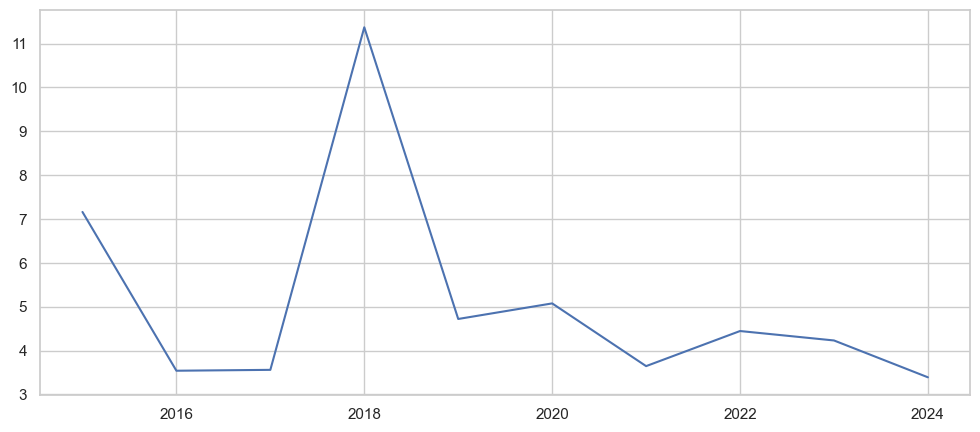

In [33]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median()

print(trend)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_trend.index, pop_trend)

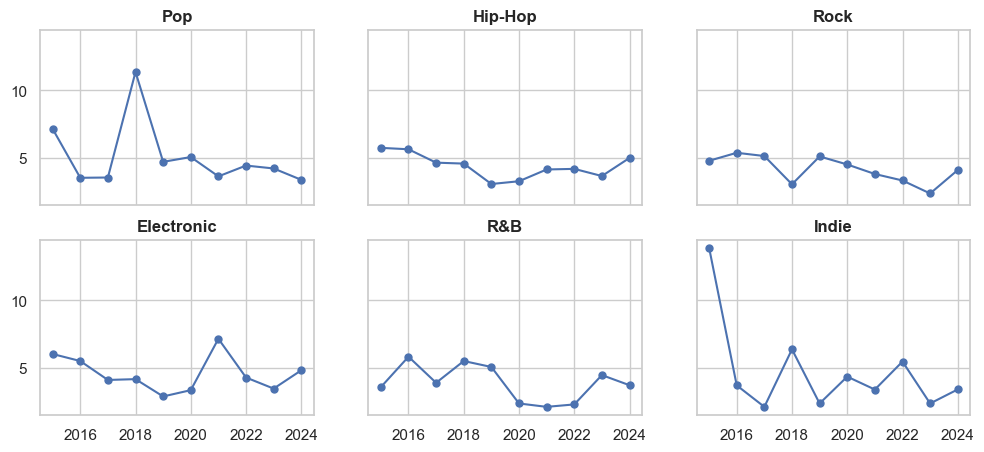

In [38]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    ax.set_title(genre, fontweight="bold")

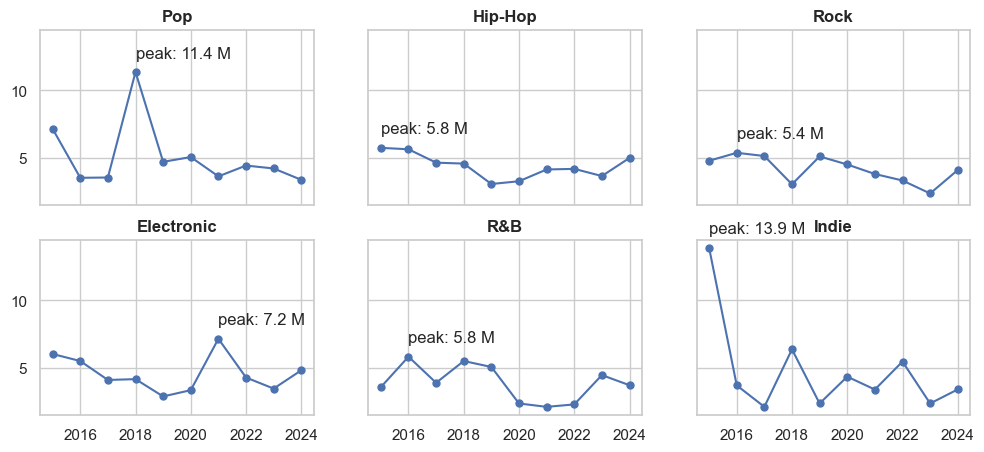

In [41]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f} M", xy=(peak.year, peak.streams_millions), xytext=(0, 10),textcoords="offset points")
    ax.set_title(genre, fontweight="bold")

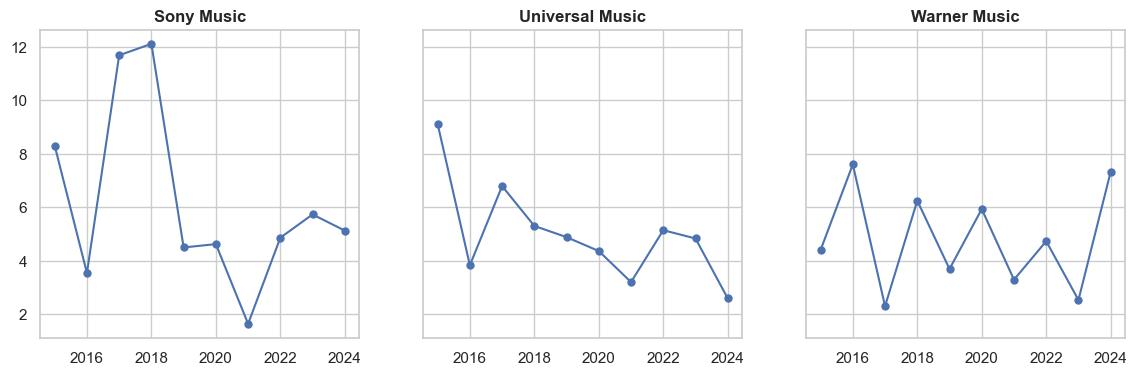

In [8]:
# Median streams by label over the years　（lab3 task)
labels = ["Sony Music", "Universal Music", "Warner Music"]
trend2 = df[df.label.isin(labels)].groupby(["year", "label"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, label in zip(axes, labels):
    subD = trend2[trend2.label == label]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    ax.set_title(label, fontweight="bold")

In [19]:
import altair as alt

# Average streams per genre, measured in millions.
chart = alt.Chart(df).mark_bar().encode(
    x="genre:N",
    y="mean(streams_millions):Q",
    color="genre:N"
)

chart

alt.Chart(...)